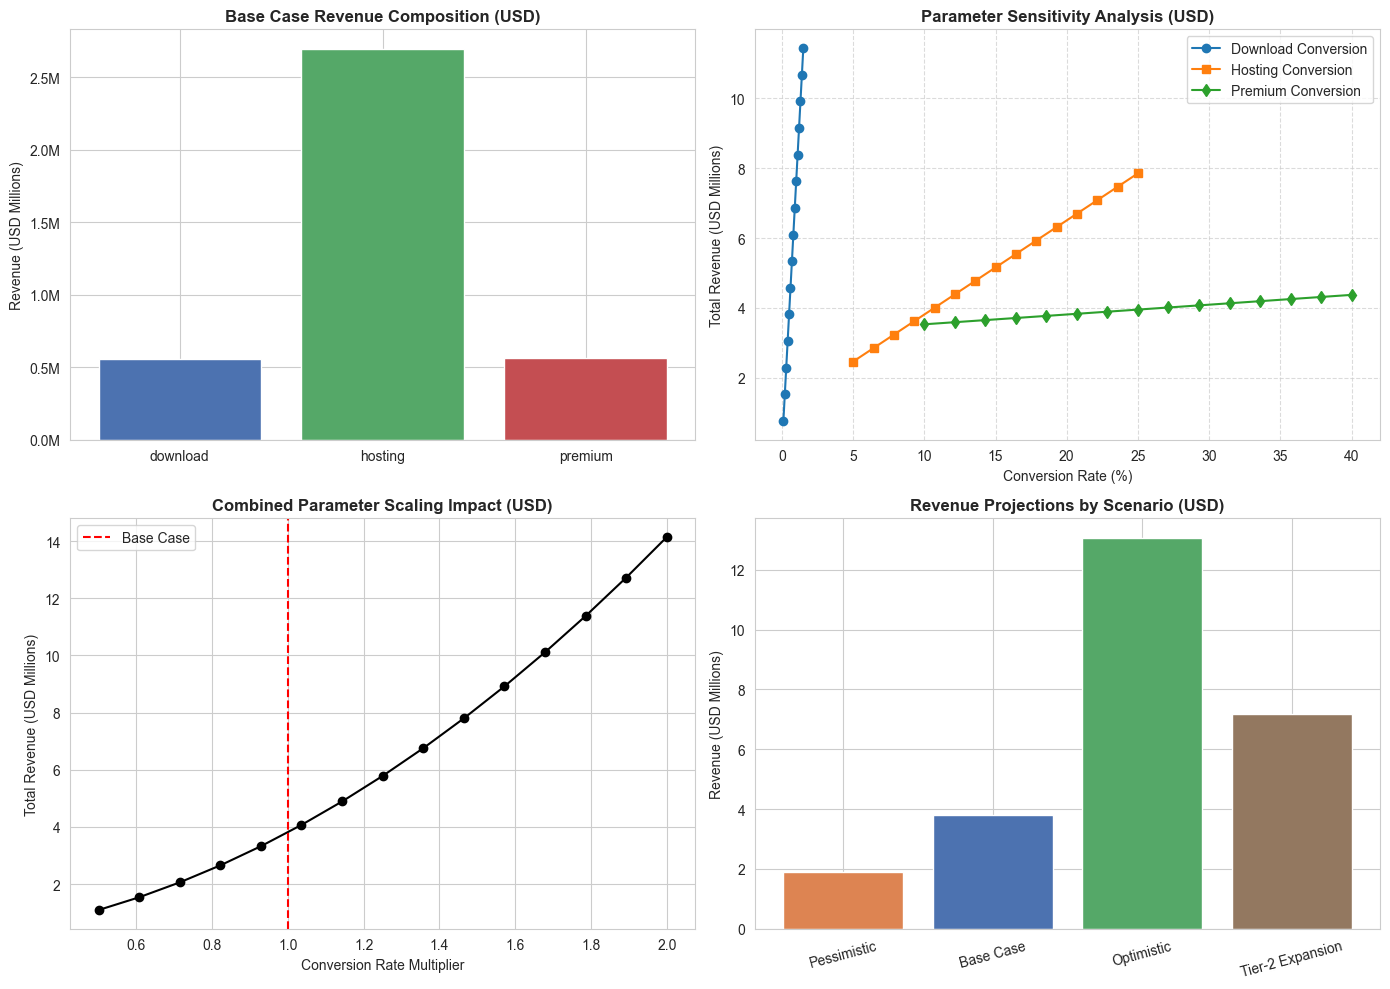

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Base parameters from business case
ACTIVE_APPLICANTS = 93.8e6  # 93.8 million active job seekers
BASE_DOWNLOAD_CONV = 0.005  # 0.5% conversion rate
BASE_HOSTING_CONV = 0.10    # 10% conversion to hosting
BASE_PREMIUM_UPGRADE = 0.20 # 20% premium template uptake
PRICES = {
    'download': 99,
    'hosting': 399 * 12,    # Annualized subscription
    'premium': 499
}
USD_CONVERSION_RATE = 0.012  # Conversion rate from INR to USD

def calculate_revenue(download_conv, hosting_conv, premium_upgrade):
    """Calculate revenue components based on conversion rates"""
    downloads = ACTIVE_APPLICANTS * download_conv
    subscribers = downloads * hosting_conv
    premium_users = downloads * premium_upgrade
    
    revenue = {
        'download': downloads * PRICES['download'],
        'hosting': subscribers * PRICES['hosting'],
        'premium': premium_users * PRICES['premium']
    }
    revenue['total'] = sum(revenue.values())
    revenue['total_usd'] = revenue['total'] * USD_CONVERSION_RATE
    return revenue

# 1. Base Case Scenario
base_revenue = calculate_revenue(BASE_DOWNLOAD_CONV, BASE_HOSTING_CONV, BASE_PREMIUM_UPGRADE)

# 2. Sensitivity Analysis Scenarios
# Vary download conversion (0.1% to 1.5%)
download_rates = np.linspace(0.001, 0.015, 15)
download_revenues = [calculate_revenue(r, BASE_HOSTING_CONV, BASE_PREMIUM_UPGRADE)['total_usd'] 
                     for r in download_rates]

# Vary hosting conversion (5% to 25%)
hosting_rates = np.linspace(0.05, 0.25, 15)
hosting_revenues = [calculate_revenue(BASE_DOWNLOAD_CONV, h, BASE_PREMIUM_UPGRADE)['total_usd'] 
                    for h in hosting_rates]

# Vary premium upgrade rate (10% to 40%)
premium_rates = np.linspace(0.10, 0.40, 15)
premium_revenues = [calculate_revenue(BASE_DOWNLOAD_CONV, BASE_HOSTING_CONV, p)['total_usd'] 
                    for p in premium_rates]

# Combined impact scenario (all rates scaled together)
scalers = np.linspace(0.5, 2.0, 15)
combined_revenues = [
    calculate_revenue(
        BASE_DOWNLOAD_CONV * s,
        BASE_HOSTING_CONV * s,
        BASE_PREMIUM_UPGRADE * s
    )['total_usd'] for s in scalers
    ]

# 3. Plotting
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

# Revenue breakdown (base case)
plt.subplot(2, 2, 1)
components = ['download', 'hosting', 'premium']
revenue_values = [base_revenue[k] * USD_CONVERSION_RATE for k in components]
plt.bar(components, revenue_values, color=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Base Case Revenue Composition (USD)', fontweight='bold')
plt.ylabel('Revenue (USD Millions)')
plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x/1e6:.1f}M')

# Sensitivity curves
plt.subplot(2, 2, 2)
plt.plot(download_rates*100, [r/1e6 for r in download_revenues], 'o-', label='Download Conversion')
plt.plot(hosting_rates*100, [r/1e6 for r in hosting_revenues], 's-', label='Hosting Conversion')
plt.plot(premium_rates*100, [r/1e6 for r in premium_revenues], 'd-', label='Premium Conversion')
plt.title('Parameter Sensitivity Analysis (USD)', fontweight='bold')
plt.xlabel('Conversion Rate (%)')
plt.ylabel('Total Revenue (USD Millions)')
plt.legend()
plt.grid(linestyle='--', alpha=0.7)

# Combined impact
plt.subplot(2, 2, 3)
plt.plot(scalers, [r/1e6 for r in combined_revenues], 'ko-')
plt.title('Combined Parameter Scaling Impact (USD)', fontweight='bold')
plt.xlabel('Conversion Rate Multiplier')
plt.ylabel('Total Revenue (USD Millions)')
plt.axvline(1.0, color='red', linestyle='--', label='Base Case')
plt.legend()

# Revenue projections comparison
plt.subplot(2, 2, 4)
scenarios = [
    ('Pessimistic', 0.003, 0.08, 0.15),
    ('Base Case', BASE_DOWNLOAD_CONV, BASE_HOSTING_CONV, BASE_PREMIUM_UPGRADE),
    ('Optimistic', 0.012, 0.15, 0.30),
    ('Tier-2 Expansion', 0.008, 0.12, 0.25)
    ]

scenario_names = [s[0] for s in scenarios]
scenario_revenues = [calculate_revenue(s[1], s[2], s[3])['total_usd']/1e6 for s in scenarios]

plt.bar(scenario_names, scenario_revenues, color=['#DD8452', '#4C72B0', '#55A868', '#937860'])
plt.title('Revenue Projections by Scenario (USD)', fontweight='bold')
plt.ylabel('Revenue (USD Millions)')
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig('revenue_sensitivity_analysis_usd.png', dpi=300)
plt.show()